In [39]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alxmamaev/flowers-recognition")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flowers-recognition' dataset.
Path to dataset files: /kaggle/input/flowers-recognition


In [40]:
!ls /kaggle/input/flowers-recognition/flowers

daisy  dandelion  rose	sunflower  tulip


In [41]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers , models
from tensorflow.keras.callbacks import EarlyStopping

In [42]:
!pip install split-folders

## Split The Data

In [43]:
import splitfolders

input_folder = "/kaggle/input/flowers-recognition/flowers"
output_folder = "/content/flowers-recognition_split"

splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

Copying files: 4317 files [00:11, 378.98 files/s] 


In [44]:
!ls /content/flowers-recognition_split

test  train  val


In [45]:
train_path = "/content/flowers-recognition_split/train"
val_path = "/content/flowers-recognition_split/val"
test_path = "/content/flowers-recognition_split/test"

In [46]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=(224, 224),
    batch_size=32
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=32
)

Found 3019 files belonging to 5 classes.
Found 644 files belonging to 5 classes.
Found 654 files belonging to 5 classes.


In [47]:
class_names = train_ds.class_names

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Number of classes: 5


In [48]:
AutoTune = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AutoTune)
val_ds = val_ds.cache().prefetch(buffer_size=AutoTune)
test_ds = test_ds.cache().prefetch(buffer_size=AutoTune)

## Sample

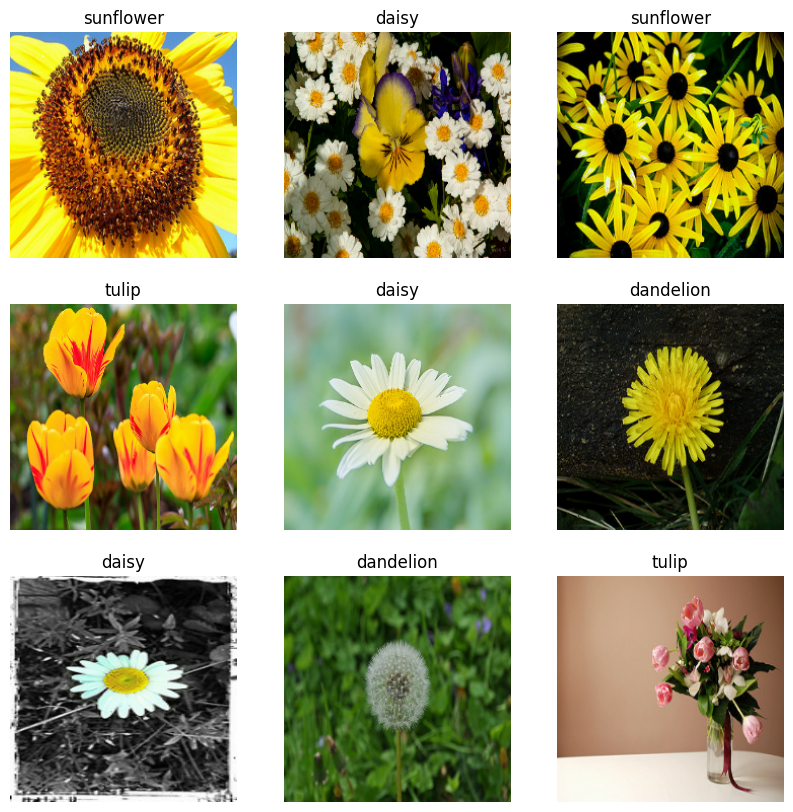

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## Modeling

In [50]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),

])

### Transfer Learning

In [51]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(include_top=False,weights="imagenet",input_shape=(224, 224, 3))

base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(len(class_names), activation="softmax")
])

In [52]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,184 (16.08 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [53]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_ds,validation_data=val_ds,epochs=30, callbacks=[early_stopping],verbose=1)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 116ms/step - accuracy: 0.7774 - loss: 0.6072 - val_accuracy: 0.9146 - val_loss: 0.2459
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.8758 - loss: 0.3466 - val_accuracy: 0.9193 - val_loss: 0.2290
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - accuracy: 0.9056 - loss: 0.2769 - val_accuracy: 0.9239 - val_loss: 0.2083
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.9149 - loss: 0.2488 - val_accuracy: 0.9255 - val_loss: 0.2108
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 88ms/step - accuracy: 0.9285 - loss: 0.2154 - val_accuracy: 0.9317 - val_loss: 0.1920
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 10s 86ms/step - accuracy: 0.9308 - loss: 0.1954 - val_accuracy: 0.9239 - val_loss: 0.2078
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - accuracy: 0.9427 - loss: 0.1693 - val_accuracy: 0.9208 - val_loss: 0.2114
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 89ms/step - accuracy: 0.9457 - loss: 0.1578 - val_accuracy: 0.9332 

In [54]:
loss , accuracy = model.evaluate(test_ds)

print(f"test loss: {loss}")
print(f"test accuracy: {accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.9327 - loss: 0.1955
test loss: 0.19553335011005402
test accuracy: 0.932721734046936


### Visuals

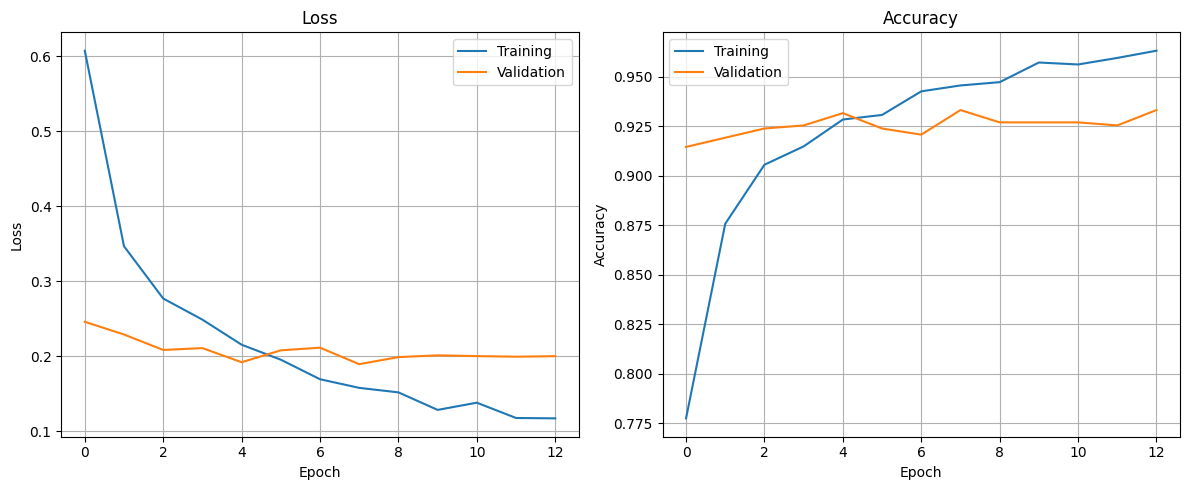

In [55]:
plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step


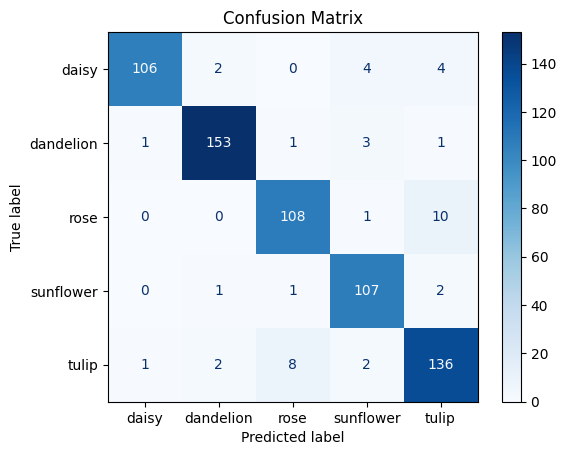

              precision    recall  f1-score   support

       daisy       0.98      0.91      0.95       116
   dandelion       0.97      0.96      0.97       159
        rose       0.92      0.91      0.91       119
   sunflower       0.91      0.96      0.94       111
       tulip       0.89      0.91      0.90       149

    accuracy                           0.93       654
   macro avg       0.93      0.93      0.93       654
weighted avg       0.93      0.93      0.93       654



In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np


y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

y_true = np.concatenate([y for x, y in test_ds], axis=0)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true,y_pred,target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step


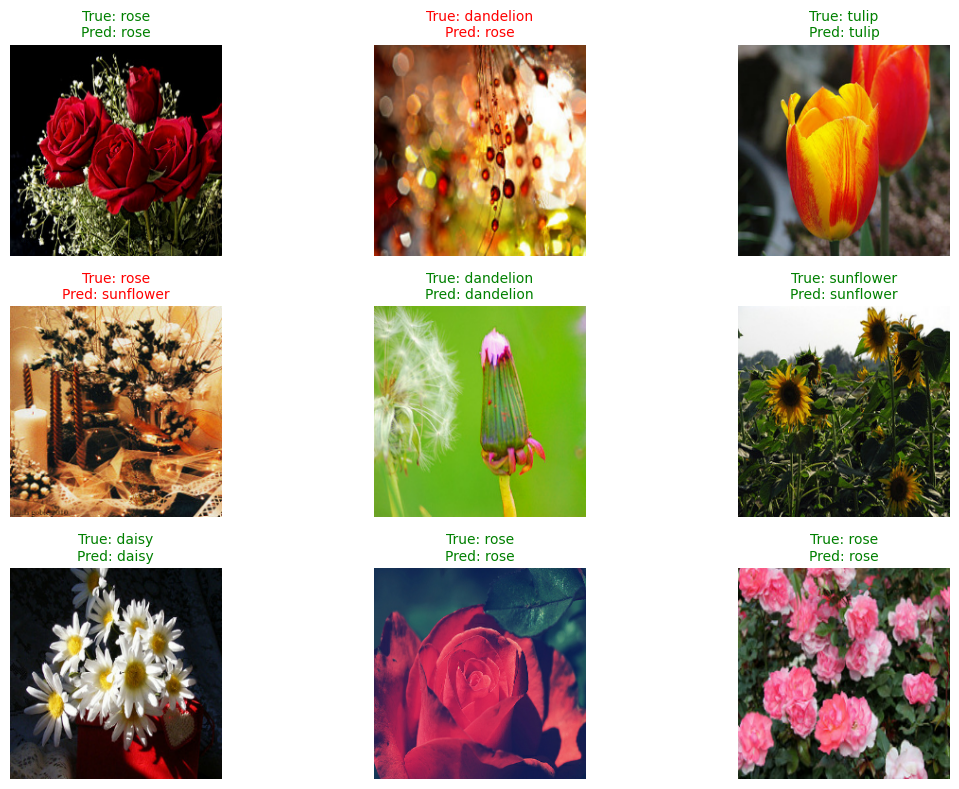

In [57]:
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(2):

    preds = model.predict(images)

    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_label = class_names[labels[i]]
        pred_label = class_names[np.argmax(preds[i])]

        color = "green" if true_label == pred_label else "red"
        plt.title(
            f"True: {true_label}\nPred: {pred_label}",
            color=color,
            fontsize=10
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

### Fine Tuning

In [58]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [59]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [60]:
history = model.fit(train_ds,validation_data=val_ds,epochs=30,callbacks=[early_stopping],verbose=1)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 27s 130ms/step - accuracy: 0.8801 - loss: 0.3834 - val_accuracy: 0.9379 - val_loss: 0.1826
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9457 - loss: 0.1529 - val_accuracy: 0.9394 - val_loss: 0.1875
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.9619 - loss: 0.1191 - val_accuracy: 0.9379 - val_loss: 0.2385
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.9705 - loss: 0.0907 - val_accuracy: 0.9255 - val_loss: 0.2714
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.9828 - loss: 0.0556 - val_accuracy: 0.9457 - val_loss: 0.2763
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 95ms/step - accuracy: 0.9818 - loss: 0.0553 - val_accuracy: 0.9503 - val_loss: 0.2921


In [61]:
loss , accuracy = model.evaluate(test_ds)

print(f"test loss: {loss}")
print(f"test accuracy: {accuracy}")

 2/21 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.8906 - loss: 0.3455

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9358 - loss: 0.2223
test loss: 0.22226369380950928
test accuracy: 0.9357798099517822
